<a href="https://colab.research.google.com/github/OgunbanjoT/Lab2AI/blob/main/AI_Assignment10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Task 1: Import Libraries and Dataset
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Automatically download the dataset into Colab local directory
!wget -O amazon_alexa.tsv https://raw.githubusercontent.com/AmitSingh2903/Alexa-Reviews-Sentiment-Analysis/master/amazon_alexa.tsv

# Load dataset into a Pandas DataFrame
data_path = 'amazon_alexa.tsv'
df = pd.read_csv(data_path, sep='\t')

# Preview the first few rows
print("Dataset Loaded Successfully! Shape:", df.shape)
display(df.head())

--2026-06-30 04:00:04--  https://raw.githubusercontent.com/AmitSingh2903/Alexa-Reviews-Sentiment-Analysis/master/amazon_alexa.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 514752 (503K) [text/plain]
Saving to: ‘amazon_alexa.tsv’

amazon_alexa.tsv    100%[===================>] 502.69K  --.-KB/s    in 0.1s    

2026-06-30 04:00:04 (3.74 MB/s) - ‘amazon_alexa.tsv’ saved [514752/514752]

Dataset Loaded Successfully! Shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


/tmp/ipykernel_472/171432568.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='feedback', data=df, palette='Set1')
/tmp/ipykernel_472/171432568.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='feedback', y='variation', data=df, errorbar=None, palette='viridis')


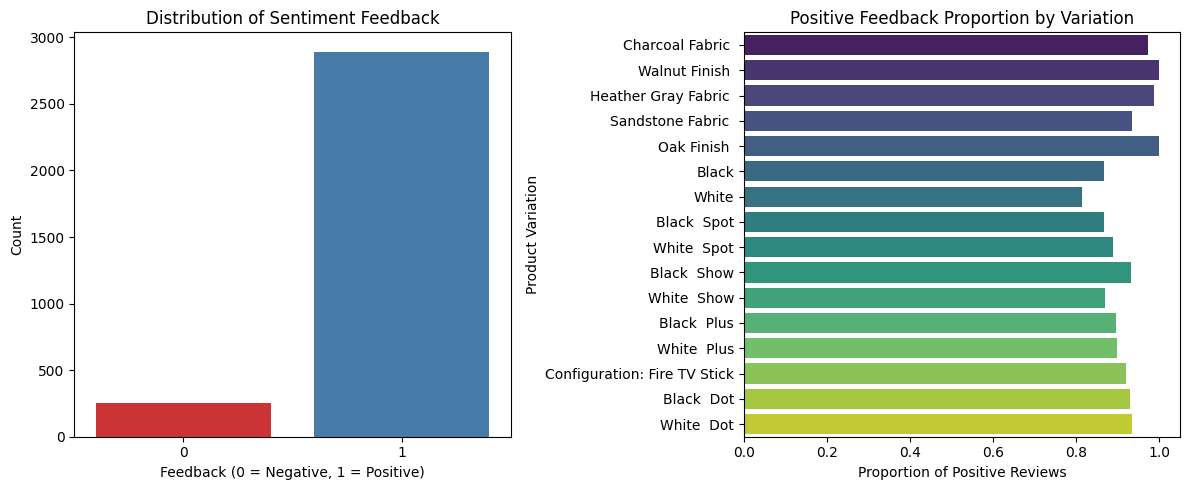

Columns remaining after dropping irrelevant items: ['variation', 'verified_reviews', 'feedback']


In [2]:
# Task 2: Data Visualization and Clean Up
# =====================================================================
plt.figure(figsize=(12, 5))

# TODO: Visualize the distribution of feedback (positive=1 / negative=0)
plt.subplot(1, 2, 1)
sns.countplot(x='feedback', data=df, palette='Set1')
plt.title('Distribution of Sentiment Feedback')
plt.xlabel('Feedback (0 = Negative, 1 = Positive)')
plt.ylabel('Count')

# TODO: Visualize the relationship between product variation and feedback
plt.subplot(1, 2, 2)
sns.barplot(x='feedback', y='variation', data=df, errorbar=None, palette='viridis')
plt.title('Positive Feedback Proportion by Variation')
plt.xlabel('Proportion of Positive Reviews')
plt.ylabel('Product Variation')

plt.tight_layout()
plt.show()

# TODO: Drop irrelevant columns ('date', 'rating')
df = df.drop(columns=['date', 'rating'])
print("Columns remaining after dropping irrelevant items:", df.columns.tolist())

In [3]:
# Task 3: One-Hot Encoding
# =====================================================================
# TODO: Perform one-hot encoding on the 'variation' column
# Using drop_first=True to avoid multicollinearity, converting true/false flags to 1/0 integers
variation_encoded = pd.get_dummies(df['variation'], prefix='var', drop_first=True).astype(int)

# Concatenate these encoded columns back to the original DataFrame and drop original 'variation'
df = pd.concat([df, variation_encoded], axis=1)
df = df.drop(columns=['variation'])

print("Shape after One-Hot Encoding variations:", df.shape)

Shape after One-Hot Encoding variations: (3150, 17)


In [4]:
# Task 4: Tokenization (Count Vectorizer)
# =====================================================================
# Clean text column from missing values before tokenizing
df['verified_reviews'] = df['verified_reviews'].fillna('')

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
text_tokenized = vectorizer.fit_transform(df['verified_reviews']).toarray()

# Convert tokenized text array into a clean dataframe
text_df = pd.DataFrame(text_tokenized, columns=vectorizer.get_feature_names_out())

# Drop the original 'verified_reviews' text column from main dataframe
df = df.drop(columns=['verified_reviews'])

# Reset indexes to avoid alignment issues when combining dataframes
df = df.reset_index(drop=True)
text_df = text_df.reset_index(drop=True)

# TODO: Combine tokenized reviews with the main dataframe
df_final = pd.concat([text_df, df], axis=1)
print("Final Dataframe Shape (Ready for modeling):", df_final.shape)

Final Dataframe Shape (Ready for modeling): (3150, 1016)


In [5]:
# Task 5: Prepare data and Split Train/Test Sets
# =====================================================================
# TODO: Split the data into features (X) and target (y)
X = df_final.drop(columns=['feedback']).values
y = df_final['feedback'].values

# TODO: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")

Training set features shape: (2520, 1015)
Testing set features shape: (630, 1015)


In [6]:
# Task 6: Train the Random Forest Classifier
# =====================================================================
# TODO: Define and train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("Random Forest model training finished successfully!")

Random Forest model training finished successfully!


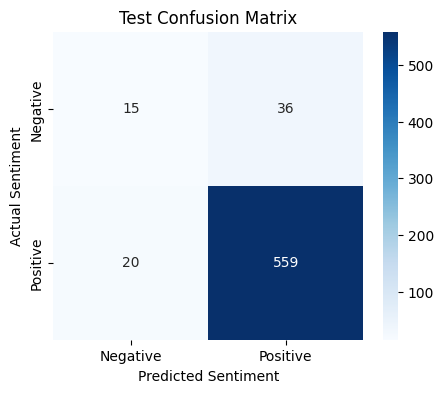


Classification Report Summary:

              precision    recall  f1-score   support

           0       0.43      0.29      0.35        51
           1       0.94      0.97      0.95       579

    accuracy                           0.91       630
   macro avg       0.68      0.63      0.65       630
weighted avg       0.90      0.91      0.90       630



In [7]:
# Task 7: Evaluate the Model
# =====================================================================
# TODO: Generate predictions for the test data
y_pred = rf_model.predict(X_test)

# TODO: Generate and Plot confusion matrix using seaborn heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Test Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

# TODO: Print classification report
print("\nClassification Report Summary:\n")
print(classification_report(y_test, y_pred))

In [8]:
# Task 8: Analyze Model Performance
# =====================================================================
# TODO: Compare training and testing accuracy and discuss model performance
train_accuracy = rf_model.score(X_train, y_train) * 100
test_accuracy = rf_model.score(X_test, y_test) * 100

print(f"Training Data Accuracy: {train_accuracy:.2f}%")
print(f"Testing Data Accuracy:  {test_accuracy:.2f}%")

print("\nPerformance Discussion:")
if train_accuracy > test_accuracy + 5:
    print("Discussion: The model is Overfitting. It scores highly on the training data but drops on the unseen testing test data.")
else:
    print("Discussion: The model is well-balanced and generalizes well to unseen testing instances.")

Training Data Accuracy: 98.93%
Testing Data Accuracy:  91.11%

Performance Discussion:
Discussion: The model is Overfitting. It scores highly on the training data but drops on the unseen testing test data.
